In [12]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Deep Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Warnings
import warnings
warnings.filterwarnings('ignore')

In [13]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [14]:
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable


In [15]:
import pandas as pd
df = pd.read_excel("Sensex_2018-2023.xlsx")
df

,Date,Open,High,Low,Close
0,2018-01-01,34059.99,34101.13,33766.15,33812.75
1,2018-01-02,33913.55,33964.14,33703.37,33812.26
2,2018-01-03,33929.61,33998.37,33765.43,33793.38
3,2018-01-04,33912.49,33995.40,33802.13,33969.64
4,2018-01-05,34021.27,34188.85,34020.84,34153.85
...,...,...,...,...,...
1461,2023-11-24,66000.29,66101.64,65894.05,65970.04
1462,2023-11-28,66063.72,66256.20,65906.65,66174.20
1463,2023-11-29,66381.26,66946.28,66374.52,66901.91
1464,2023-11-30,66963.20,67069.89,66610.35,66988.44


**Basic EDA**

In [16]:
df.shape

(1466, 5)

In [17]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1466 non-null   datetime64[ns]
 1   Open    1466 non-null   float64       
 2   High    1466 non-null   float64       
 3   Low     1466 non-null   float64       
 4   Close   1466 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.4 KB


In [ ]:
df.describe()

**Missing Value**

In [20]:
print(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


**Convert Date column to datetime (if not already)**

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

**Plot the closing price trend**

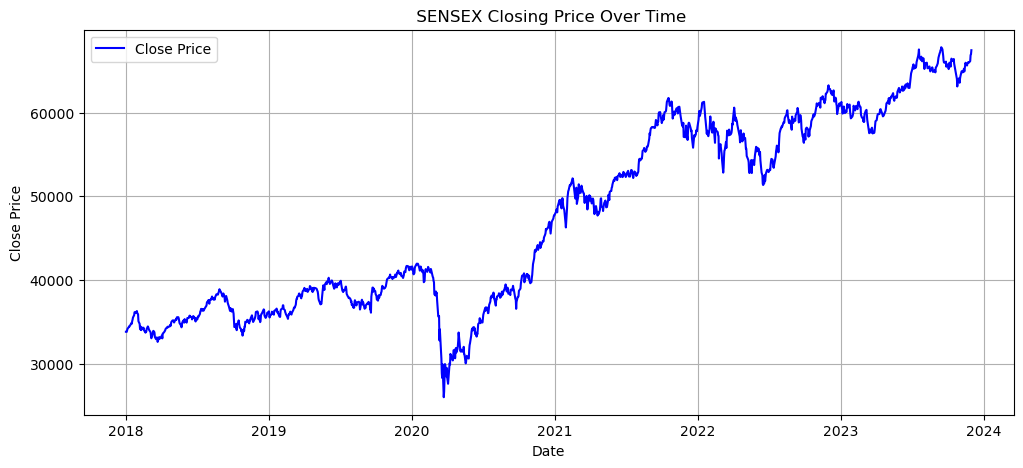

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title(' SENSEX Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


**Correlation heatmap**

In [ ]:
df = pd.read_excel("Sensex_2018-2023.xlsx")

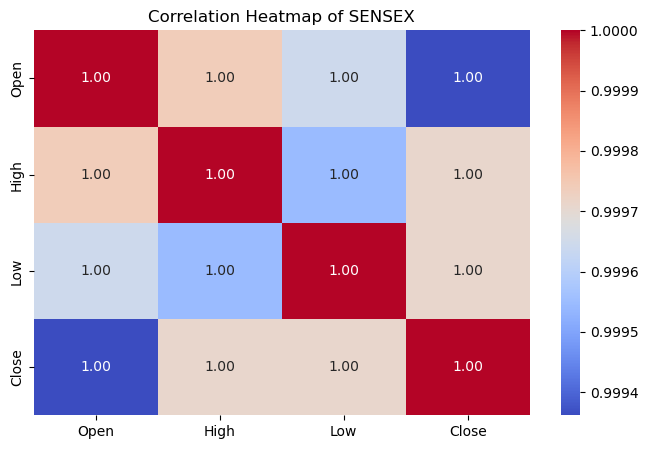

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Read the correct local path
df = pd.read_excel("Sensex_2018-2023.xlsx")

# Convert price columns to numeric (replace '-' with NaN)
for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['Open', 'High', 'Low', 'Close'])

# Plot correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of SENSEX')
plt.show()


# Classical Machine Learning Models

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
# 1️⃣ Load your dataset (update path if needed)
import pandas as pd

df = pd.read_csv("BANKNIFTY_2020_2025_CLEAN.csv")


In [47]:
# 2️⃣ Clean the data
for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['Open', 'High', 'Low', 'Close'])
df = df.sort_values('Date')

In [49]:
# 3️⃣ Define features and target
X = df[['Open', 'High', 'Low']]
y = df['Close']

In [50]:
# 4️⃣ Split into train (80%) and test (20%) — no shuffle for time series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [51]:
# 5️⃣ Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
# 6️⃣ Predict on test data
y_pred = model.predict(X_test)


In [53]:
# 7️⃣ Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error: 28466.5261
R² Score: 0.9896


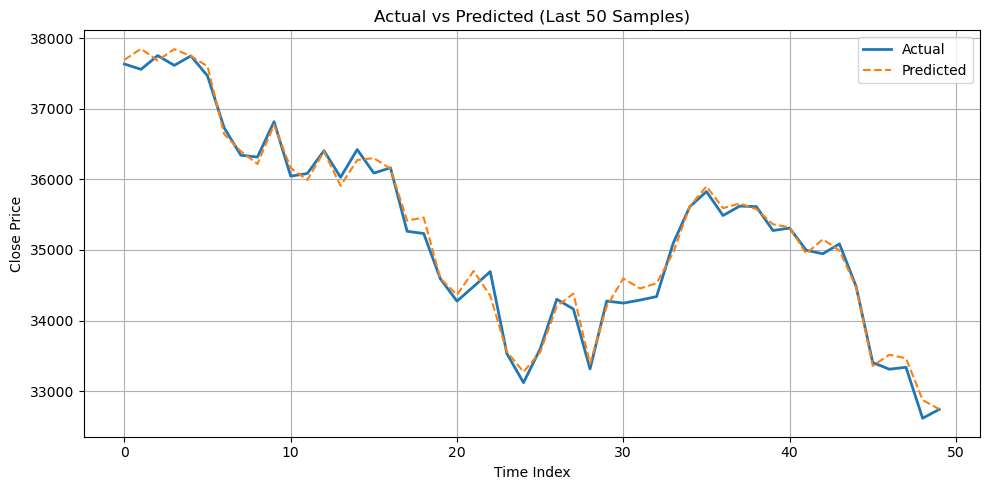

In [56]:
import matplotlib.pyplot as plt

N = 50  # number of recent samples to display

plt.figure(figsize=(10,5))
plt.plot(y_test.values[-N:], label='Actual', linewidth=2)
plt.plot(y_pred[-N:], label='Predicted', linestyle='--')

plt.title(f'Actual vs Predicted (Last {N} Samples)')
plt.xlabel('Time Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**RandomForestRegressor**

In [57]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [59]:
# Load the Excel file
data = pd.read_csv("BANKNIFTY_2020_2025_CLEAN.csv")

In [60]:
# Display columns to confirm
print("Columns in file:", data.columns.tolist())
print(data.head())

Columns in file: ['Date', 'Open', 'High', 'Low', 'Close']
                        Date       Open       High        Low     Close
0  2020-01-01 09:15:00+05:30  32237.900  32348.000  32057.199  32102.90
1  2020-01-02 09:15:00+05:30  32133.150  32465.449  32121.400  32443.85
2  2020-01-03 09:15:00+05:30  32326.949  32329.801  31960.400  32069.25
3  2020-01-06 09:15:00+05:30  31910.449  31914.449  31170.551  31237.15
4  2020-01-07 09:15:00+05:30  31598.051  31851.449  31200.900  31399.40


In [61]:
# ✅ Feature selection
X = data[['Open', 'High', 'Low']]   # independent variables
y = data['Close']                   # target variable

In [62]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
# Initialize and train RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [64]:
# Predict on test data
y_pred = rf.predict(X_test)

In [65]:
# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Regressor Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")



Random Forest Regressor Performance:
MAE: 168.5719
RMSE: 217.6026
R² Score: 0.9989


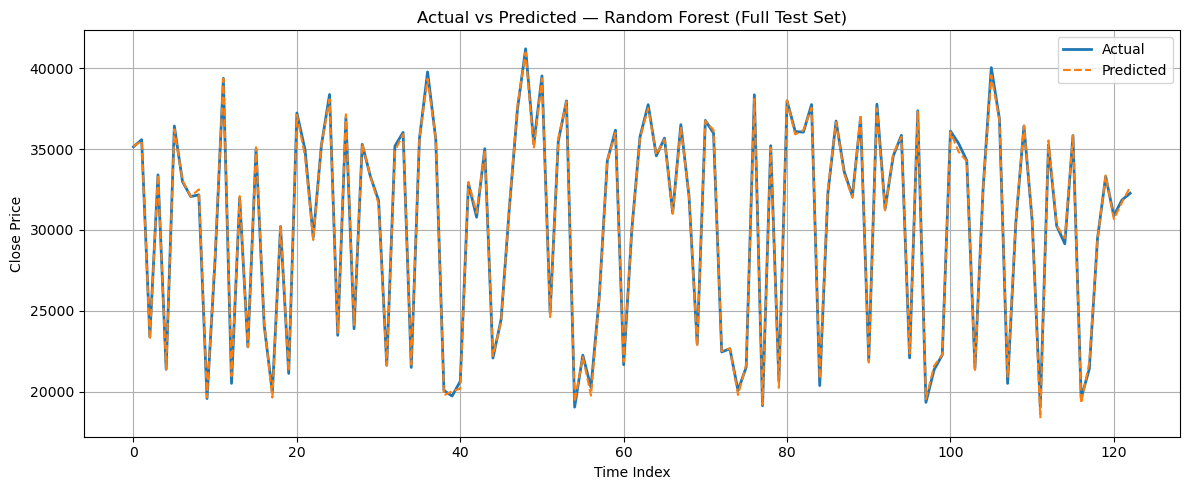

In [67]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linestyle='--')

plt.title('Actual vs Predicted — Random Forest (Full Test Set)')
plt.xlabel('Time Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# DATA PREPARATION FOR RNN, LSTM, CNN, GRU, Attention Based LSTM.

Import Libraries

In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout, Attention, Input
from tensorflow.keras import Model


Load and Normalize Data

In [70]:
# Load data
data = pd.read_csv("BANKNIFTY_2020_2025_CLEAN.csv")

# Use relevant columns
data = data[['Open', 'High', 'Low', 'Close']]

# Scale all features between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Convert to DataFrame for clarity
scaled_df = pd.DataFrame(scaled_data, columns=['Open', 'High', 'Low', 'Close'])


Create Sequences for Time-Series Input

Deep learning models like LSTM/GRU need sequences.
We’ll create a lookback window (e.g., last 10 days → predict next Close).

In [71]:
def create_sequences(df, lookback=10):
    X, y = [], []
    for i in range(lookback, len(df)):
        X.append(df.iloc[i-lookback:i, :-1].values)  # all features except Close
        y.append(df.iloc[i, -1])                     # next day's Close
    return np.array(X), np.array(y)

lookback = 10
X, y = create_sequences(scaled_df, lookback)


# Recurrent Neural Network (RNN) for NIFTY50 Close Prediction

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [73]:
# 1️ Load your data
# Assuming df['Close'] contains the stock prices
data = df['Close'].values.reshape(-1, 1)

In [74]:
# 2️ Train-test split (80/20)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [75]:
# 3️ Scale data (fit only on train)
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

In [76]:
# 4️ Create sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)
X_test, y_test = create_sequences(scaled_test, seq_length)

# Reshape for RNN [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [77]:
# 5️ Define evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [78]:
# 6️ RNN Model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64, activation='tanh', input_shape=(X_train.shape[1], 1)))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# 7️ Train RNN with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.1662 - val_loss: 0.0103
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0279 - val_loss: 0.0056
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0188 - val_loss: 0.0018
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0131 - val_loss: 0.0020
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0121 - val_loss: 0.0015
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0094 - val_loss: 0.0014
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0094 - val_loss: 0.0013
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0082 - val_loss: 0.0014
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0071 - val_loss: 0.0012
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0072 - val_loss: 0.0014
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0064 - val_loss: 0.0013
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0056 - val_loss: 0.0012


In [80]:
# 8 Predictions and inverse scaling
rnn_train_pred = scaler.inverse_transform(rnn_model.predict(X_train))
rnn_test_pred = scaler.inverse_transform(rnn_model.predict(X_test))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [82]:
# 9️ Evaluate RNN
rnn_mae, rnn_mse, rnn_rmse, rnn_r2 = evaluate_model(y_test_actual, rnn_test_pred)

print("\n📊 RNN Performance:")
print(f"MAE  : {rnn_mae:.4f}")
print(f"MSE  : {rnn_mse:.4f}")
print(f"RMSE : {rnn_rmse:.4f}")
print(f"R²   : {rnn_r2:.4f}")



📊 RNN Performance:
MAE  : 605.1208
MSE  : 611979.5563
RMSE : 782.2912
R²   : 0.6822


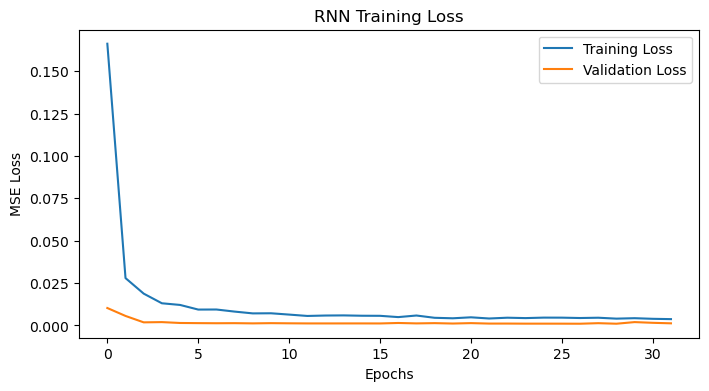

In [81]:
# 10 Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('RNN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

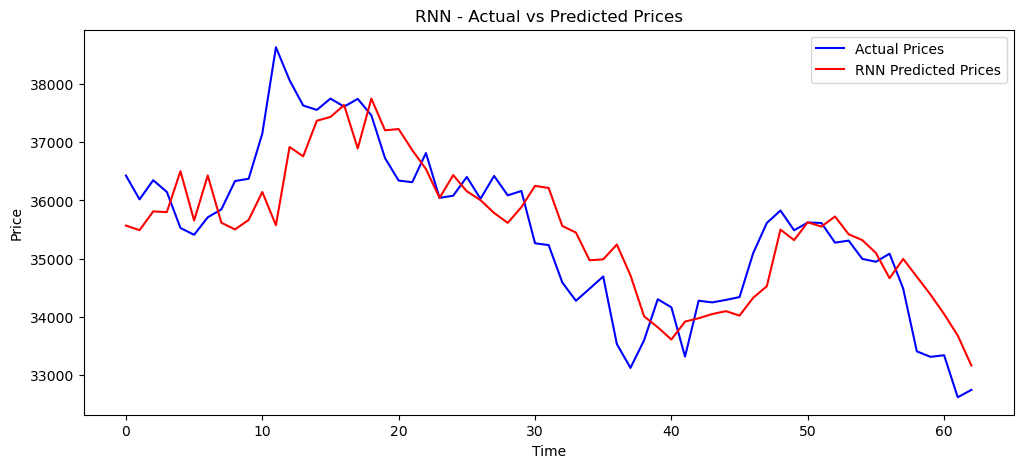

In [83]:
# 1️1 Plot actual vs predicted prices
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(rnn_test_pred, label='RNN Predicted Prices', color='red')
plt.title('RNN - Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# LSTM Model

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [87]:
# 1️ Load your data
# Assuming df['Close'] contains the stock prices
data = df['Close'].values.reshape(-1, 1)

In [88]:
# 2️ Train-test split (80/20)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [89]:
# 3️ Scale data (fit only on train)
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


In [90]:
# 4️ Create sequences (past 60 days → next day)
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)
X_test, y_test = create_sequences(scaled_test, seq_length)

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [91]:
# 5️ Define evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [92]:
# 6️ LSTM Model
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

In [93]:
# 7️ Train LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.2611 - val_loss: 0.1108
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0374 - val_loss: 0.0470
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0202 - val_loss: 0.0132
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0169 - val_loss: 0.0156
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0105 - val_loss: 0.0023
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0086 - val_loss: 0.0027
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0077 - val_loss: 0.0035
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0074 - val_loss: 0.0033
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0079 - val_loss: 0.0023
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0056 - val_loss: 0.0023
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0054 - val_loss: 0.00

In [94]:
# 8️ Predictions and inverse scaling
lstm_train_pred = scaler.inverse_transform(lstm_model.predict(X_train))
lstm_test_pred = scaler.inverse_transform(lstm_model.predict(X_test))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [95]:
# 9️ Evaluate LSTM
lstm_mae, lstm_mse, lstm_rmse, lstm_r2 = evaluate_model(y_test_actual, lstm_test_pred)

print("\n📊 LSTM Performance:")
print(f"MAE  : {lstm_mae:.4f}")
print(f"MSE  : {lstm_mse:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")



📊 LSTM Performance:
MAE  : 971.0647
MSE  : 1357692.1323
RMSE : 1165.2005
R²   : 0.2950


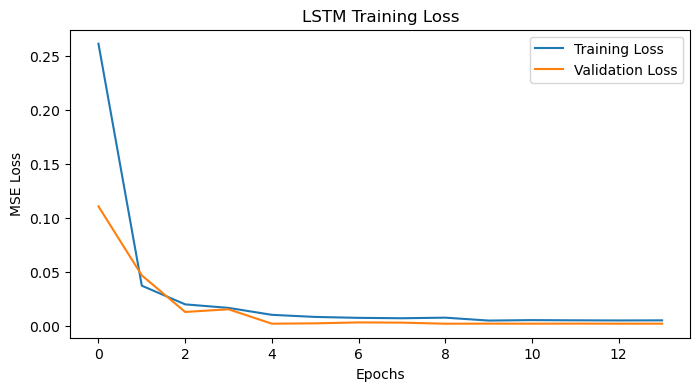

In [96]:
# 10 Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

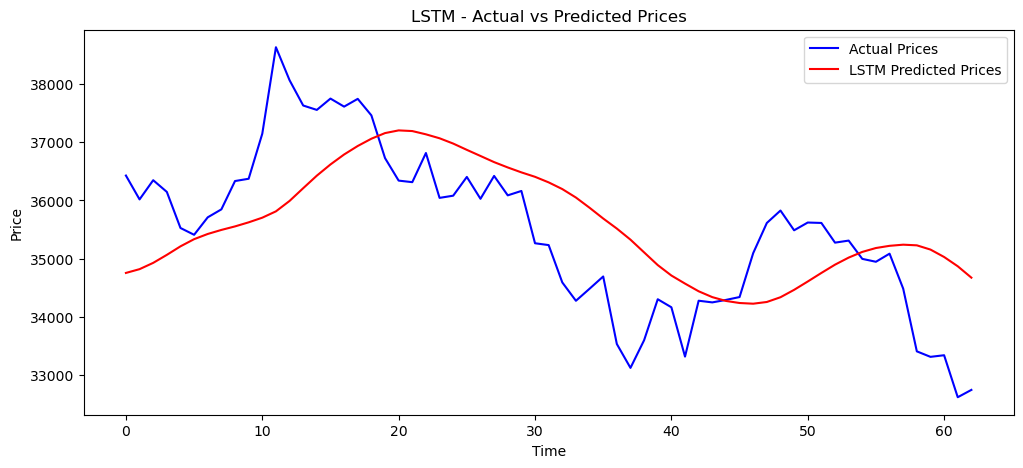

In [97]:

# 1️1️ Plot actual vs predicted prices
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(lstm_test_pred, label='LSTM Predicted Prices', color='red')
plt.title('LSTM - Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# CNN Model

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [99]:
# ==========================
# 1️⃣ Load your data
# ==========================
# Assuming df['Close'] contains the stock prices
data = df['Close'].values.reshape(-1, 1)

In [100]:
# ==========================
# 2️⃣ Train-test split (80/20)
# ==========================
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [101]:
# ==========================
# 3️⃣ Scale data (fit only on train)
# ==========================
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

In [102]:
# ==========================
# 4️⃣ Create sequences (past 60 days → next day)
# ==========================
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)
X_test, y_test = create_sequences(scaled_test, seq_length)

# Reshape for CNN [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [103]:
# ==========================
# 5️⃣ Define evaluation function
# ==========================
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [104]:
# ==========================
# 6️⃣ CNN Model
# ==========================
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mean_squared_error')
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,157 (363.89 KB)

 Trainable params: 93,157 (363.89 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# ==========================
# 7️⃣ Train CNN
# ==========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.1085 - val_loss: 0.0133
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0268 - val_loss: 0.0087
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0173 - val_loss: 0.0141
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0121 - val_loss: 0.0022
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0093 - val_loss: 0.0123
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0065 - val_loss: 0.0025
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0045 - val_loss: 0.0033
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0044 - val_loss: 0.0035


In [106]:
# ==========================
# 8️⃣ Predictions and inverse scaling
# ==========================
cnn_train_pred = scaler.inverse_transform(cnn_model.predict(X_train))
cnn_test_pred = scaler.inverse_transform(cnn_model.predict(X_test))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [107]:
# ==========================
# 9️⃣ Evaluate CNN
# ==========================
cnn_mae, cnn_mse, cnn_rmse, cnn_r2 = evaluate_model(y_test_actual, cnn_test_pred)

print("\n📊 CNN Performance:")
print(f"MAE  : {cnn_mae:.4f}")
print(f"MSE  : {cnn_mse:.4f}")
print(f"RMSE : {cnn_rmse:.4f}")
print(f"R²   : {cnn_r2:.4f}")


📊 CNN Performance:
MAE  : 876.7268
MSE  : 1302821.3663
RMSE : 1141.4120
R²   : 0.3235


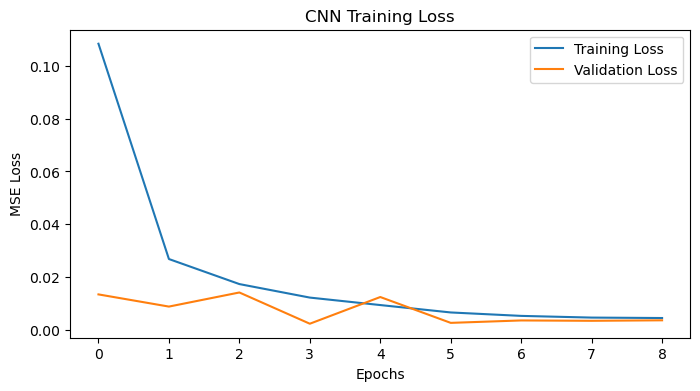

In [108]:
# ==========================
# 🔟 Plot training & validation loss
# ==========================
plt.figure(figsize=(8,4))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

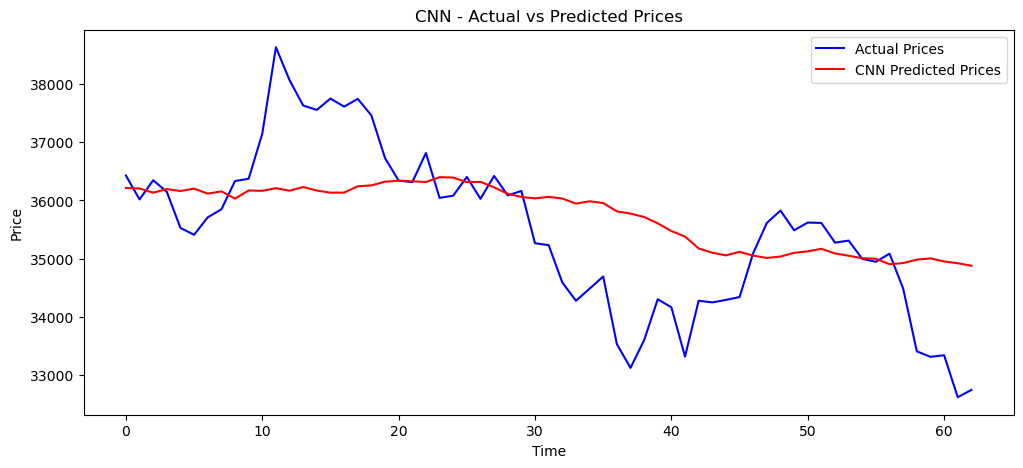

In [109]:
# ==========================
# 1️⃣1️⃣ Plot actual vs predicted prices
# ==========================
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(cnn_test_pred, label='CNN Predicted Prices', color='red')
plt.title('CNN - Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# GRU Model

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [111]:
# ==========================
# 1️⃣ Load your data
# ==========================
# Assuming df['Close'] contains the stock prices
data = df['Close'].values.reshape(-1, 1)


In [112]:
# ==========================
# 2️⃣ Train-test split (80/20)
# ==========================
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [113]:
# ==========================
# 3️⃣ Scale data (fit only on train)
# ==========================
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

In [114]:
# ==========================
# 4️⃣ Create sequences (past 60 days → next day)
# ==========================
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(scaled_train, seq_length)
X_test, y_test = create_sequences(scaled_test, seq_length)

# Reshape for GRU [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [115]:
# ==========================
# 5️⃣ Define evaluation function
# ==========================
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [116]:
# ==========================
# 6️⃣ GRU Model
# ==========================
gru_model = Sequential([
    GRU(64, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
# ==========================
# 7️⃣ Train GRU
# ==========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - loss: 0.3320 - val_loss: 0.2671
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0905 - val_loss: 0.0227
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0248 - val_loss: 0.0142
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0327 - val_loss: 0.0022
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0161 - val_loss: 0.0077
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0154 - val_loss: 0.0113
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0128 - val_loss: 0.0049
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0110 - val_loss: 0.0013
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0091 - val_loss: 0.0013
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0080 - val_loss: 0.0020
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0064 - val_loss: 0.0018
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0064 - val_loss: 0.0012

In [118]:
# ==========================
# 8️⃣ Predictions and inverse scaling
# ==========================
gru_train_pred = scaler.inverse_transform(gru_model.predict(X_train))
gru_test_pred = scaler.inverse_transform(gru_model.predict(X_test))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [119]:
# ==========================
# 9️⃣ Evaluate GRU
# ==========================
gru_mae, gru_mse, gru_rmse, gru_r2 = evaluate_model(y_test_actual, gru_test_pred)

print("\n📊 GRU Performance:")
print(f"MAE  : {gru_mae:.4f}")
print(f"MSE  : {gru_mse:.4f}")
print(f"RMSE : {gru_rmse:.4f}")
print(f"R²   : {gru_r2:.4f}")


📊 GRU Performance:
MAE  : 486.0259
MSE  : 396413.3204
RMSE : 629.6136
R²   : 0.7942


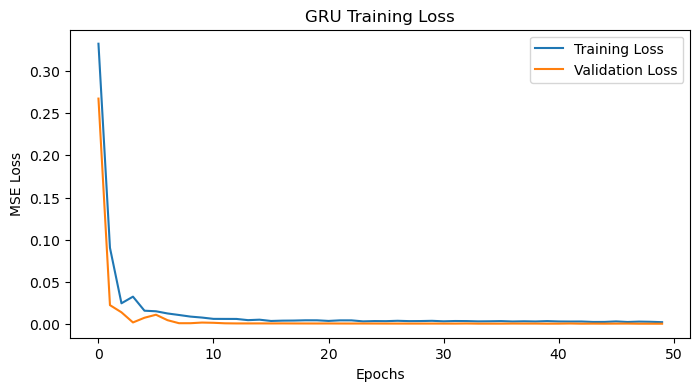

In [120]:
# ==========================
# 🔟 Plot training & validation loss
# ==========================
plt.figure(figsize=(8,4))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

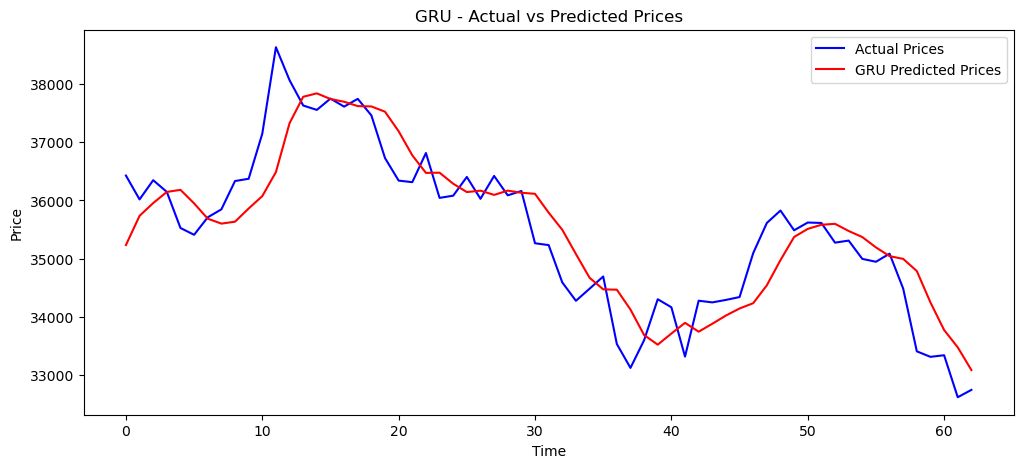

In [121]:
# ==========================
# 1️⃣1️⃣ Plot actual vs predicted prices
# ==========================
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(gru_test_pred, label='GRU Predicted Prices', color='red')
plt.title('GRU - Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Attention-Based LSTM Model

In [122]:
from tensorflow.keras.layers import Lambda


In [123]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [124]:
# ================================
# 1️⃣ Define Attention-LSTM model
# ================================
def create_attention_lstm(input_shape):
    inputs = Input(shape=input_shape)

    # LSTM encoder
    lstm_out = LSTM(64, return_sequences=True)(inputs)

    # Attention mechanism
    attention = Attention()([lstm_out, lstm_out])
    attention = GlobalAveragePooling1D()(attention)  # ✅ Keras-friendly pooling

    # Fully-connected layers
    dense1 = Dense(64, activation='relu')(attention)
    dropout1 = Dropout(0.3)(dense1)
    dense2 = Dense(32, activation='relu')(dropout1)
    outputs = Dense(1)(dense2)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


In [125]:
# ================================
# 2️⃣ Build and Train Model
# ================================
input_shape = (X_train.shape[1], 1)
attention_model = create_attention_lstm(input_shape)
attention_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = attention_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 64)    │     16,896 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 60, 64)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,169 (90.50 KB)

 Trainable params: 23,169 (90.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step - loss: 0.2918 - val_loss: 0.2780
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.1147 - val_loss: 0.0150
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0574 - val_loss: 0.0024
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0339 - val_loss: 0.0149
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0399 - val_loss: 0.0028
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0307 - val_loss: 0.0048
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0303 - val_loss: 0.0031
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0249 - val_loss: 0.0023
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0282 - val_loss: 0.0024
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.0269 - val_loss: 0.0022
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0239 - val_loss: 0.0021
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0249 - val_loss

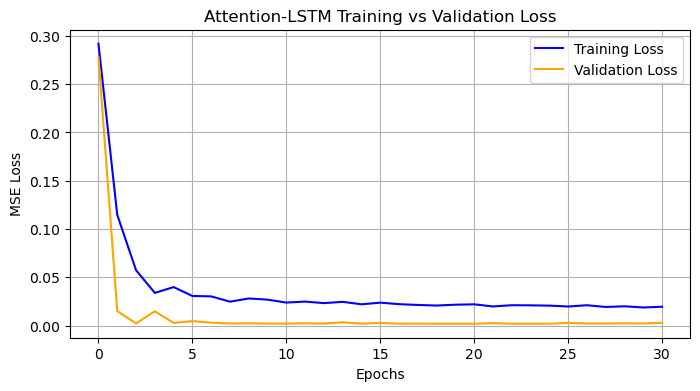

In [126]:
# =======================================
# ✅ Plot Training vs Validation Loss
# =======================================
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Attention-LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
# =======================================
# ✅ Predictions and Inverse Transform
# =======================================
train_pred = attention_model.predict(X_train)
test_pred = attention_model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [128]:
# =======================================
# ✅ Evaluate Performance
# =======================================
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

mae, mse, rmse, r2 = evaluate_model(y_test_actual, test_pred)

print("\n📊 Attention-LSTM Model Performance:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")



📊 Attention-LSTM Model Performance:
MAE  : 887.8160
MSE  : 1192923.4033
RMSE : 1092.2103
R²   : 0.3806


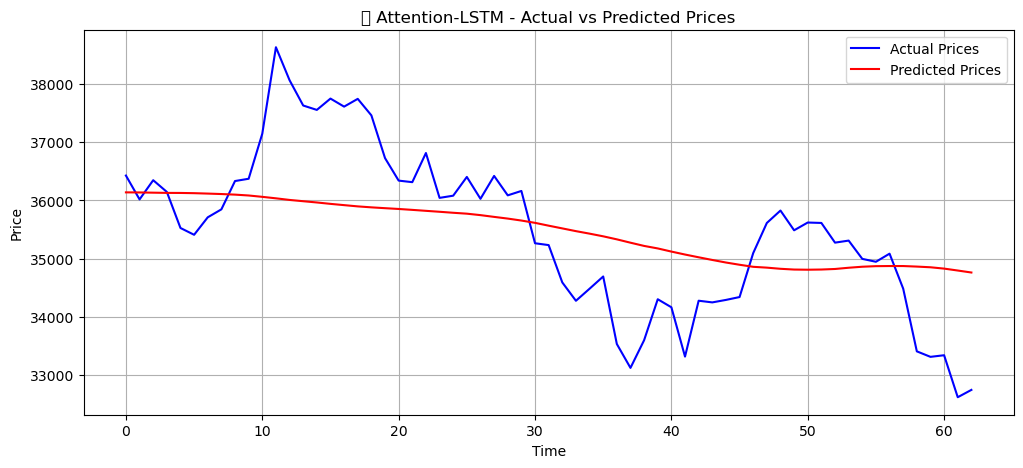

In [129]:
# =======================================
# ✅ Plot Actual vs Predicted Prices
# =======================================
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual Prices', color='blue')
plt.plot(test_pred, label='Predicted Prices', color='red')
plt.title('📈 Attention-LSTM - Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/stepWARNING:tensorflow:6 out of the last 20 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000029F54BD2200> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 765ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step

📊 Deep Learning Models Performance Compar

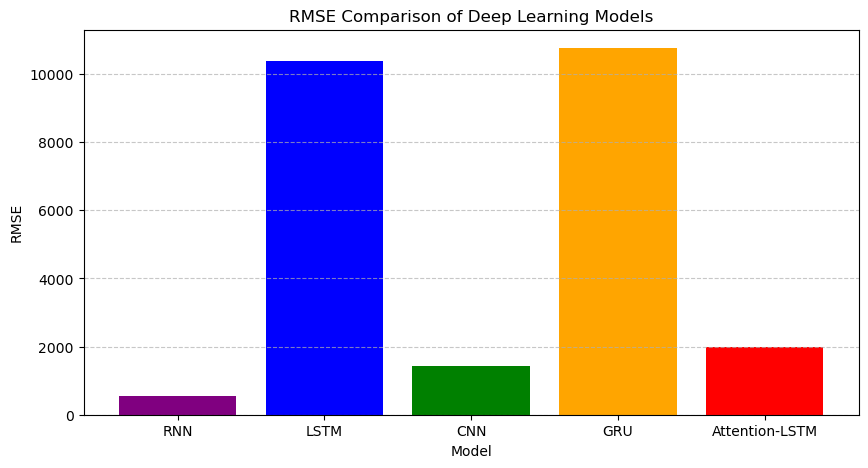

In [130]:
# ==========================================
# 📦 Import Libraries
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout, Input, Attention, Lambda, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# Helper: Model Evaluation Function
# ==========================================
def evaluate_model(model, X_test, y_test, scaler):
    y_pred = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae = mean_absolute_error(y_test_actual, y_pred)
    mse = mean_squared_error(y_test_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred)
    return mae, mse, rmse, r2

# ==========================================
# ⚙️ Common Settings
# ==========================================
input_shape = (X_train.shape[1], 1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

results = {}

# ==========================================
# 1️⃣ RNN Model
# ==========================================
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=False, input_shape=input_shape),
    Dense(32, activation='relu'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
results['RNN'] = evaluate_model(rnn_model, X_test, y_test, scaler)

# ==========================================
# 2️⃣ LSTM Model
# ==========================================
lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=input_shape),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
results['LSTM'] = evaluate_model(lstm_model, X_test, y_test, scaler)

# ==========================================
# 3️⃣ CNN Model
# ==========================================
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')

cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
results['CNN'] = evaluate_model(cnn_model, X_test, y_test, scaler)

# ==========================================
# 4️⃣ GRU Model
# ==========================================
gru_model = Sequential([
    GRU(64, return_sequences=False, input_shape=input_shape),
    Dense(32, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
results['GRU'] = evaluate_model(gru_model, X_test, y_test, scaler)

# ==========================================
# 5️⃣ Attention-based LSTM (Luong-style)
# ==========================================
def create_attention_lstm(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    last_hidden = Lambda(lambda x: x[:, -1:, :])(lstm_out)
    context = Attention()([last_hidden, lstm_out])
    context = Lambda(lambda x: tf.squeeze(x, axis=1))(context)
    last_hidden_squeezed = Lambda(lambda x: tf.squeeze(x, axis=1))(last_hidden)
    combined = Concatenate()([context, last_hidden_squeezed])
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

att_model = create_attention_lstm(input_shape)
att_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, callbacks=[early_stop], verbose=0)
results['Attention-LSTM'] = evaluate_model(att_model, X_test, y_test, scaler)

# ==========================================
# 📊 Show Comparison Results
# ==========================================
import pandas as pd

metrics_df = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'R²']).T
print("\n📊 Deep Learning Models Performance Comparison:")
print(metrics_df)

# ==========================================
# 📈 Visualize Comparison
# ==========================================
plt.figure(figsize=(10,5))
plt.bar(metrics_df.index, metrics_df['RMSE'], color=['purple','blue','green','orange','red'])
plt.title('RMSE Comparison of Deep Learning Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


In [131]:
# Example placeholders — replace these with your actual model prediction results
y_pred_rnn = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_cnn = cnn_model.predict(X_test)
y_pred_gru = gru_model.predict(X_test)
y_pred_attn = attention_model.predict(X_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [132]:
# Assuming your scaler was fit on a single 'Close' column
y_pred_rnn = scaler.inverse_transform(y_pred_rnn)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_pred_cnn = scaler.inverse_transform(y_pred_cnn)
y_pred_gru = scaler.inverse_transform(y_pred_gru)
y_pred_attn = scaler.inverse_transform(y_pred_attn)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


In [133]:
import numpy as np
import pandas as pd

# =====================================================
# Accuracy Functions
# =====================================================

# 1️⃣ Direction Accuracy — how often the model predicts correct up/down movement
def direction_accuracy(y_true, y_pred):
    actual_dir = np.sign(np.diff(y_true.flatten()))
    pred_dir = np.sign(np.diff(y_pred.flatten()))
    return np.mean(actual_dir == pred_dir) * 100

# 2️⃣ Tolerance Accuracy — % of predictions within ±2% of actual values
def tolerance_accuracy(y_true, y_pred, tolerance=0.02):
    relative_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(relative_error <= tolerance) * 100


# =====================================================
# Calculate Accuracy for All Models
# =====================================================

# Dictionary of model predictions
models = {
    "RNN": y_pred_rnn,
    "LSTM": y_pred_lstm,
    "CNN": y_pred_cnn,
    "GRU": y_pred_gru,
    "Attention-LSTM": y_pred_attn
}

# Evaluate accuracies
accuracy_results = {}
for name, y_pred in models.items():
    dir_acc = direction_accuracy(y_test_actual, y_pred)
    tol_acc = tolerance_accuracy(y_test_actual, y_pred, tolerance=0.02)
    accuracy_results[name] = {
        "Direction Accuracy (%)": dir_acc,
        "±2% Tolerance Accuracy (%)": tol_acc
    }

# Convert to DataFrame for easy viewing
acc_df = pd.DataFrame(accuracy_results).T.round(2)

# Display
print("\n📊 Accuracy Comparison of Deep Learning Models:\n")
print(acc_df)



📊 Accuracy Comparison of Deep Learning Models:

                Direction Accuracy (%)  ±2% Tolerance Accuracy (%)
RNN                              46.77                       79.37
LSTM                             48.39                        0.00
CNN                              50.00                       47.62
GRU                              50.00                        0.00
Attention-LSTM                   50.00                       49.21


<Figure size 1000x600 with 0 Axes>

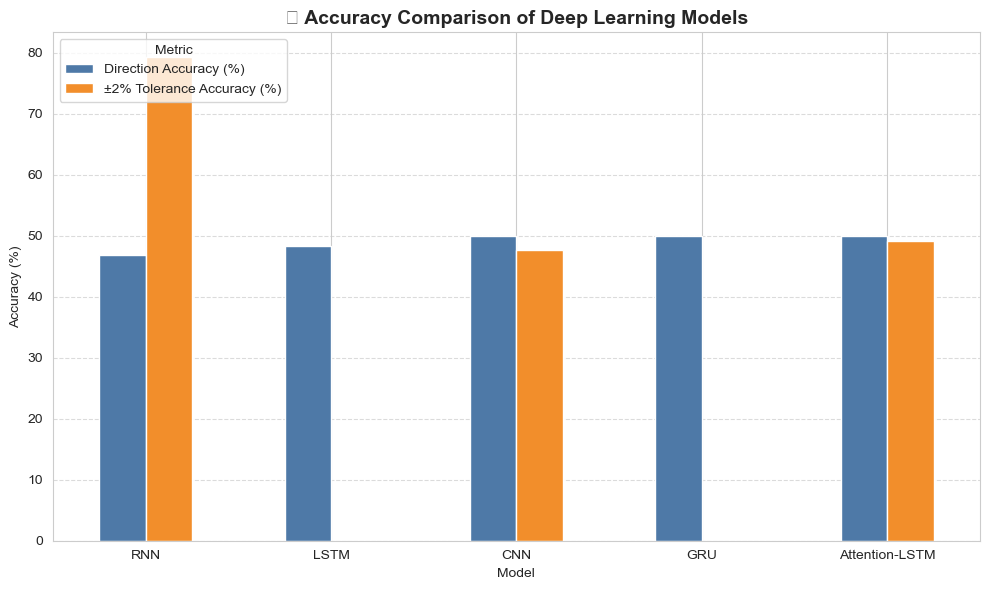

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot both accuracy metrics side by side
acc_df.plot(kind='bar', figsize=(10, 6), color=['#4e79a7', '#f28e2b'])
plt.title('📊 Accuracy Comparison of Deep Learning Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.legend(title='Metric', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [135]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ========================================
# Metric functions
# ========================================
def direction_accuracy(y_true, y_pred):
    actual_dir = np.sign(np.diff(y_true.flatten()))
    pred_dir = np.sign(np.diff(y_pred.flatten()))
    return np.mean(actual_dir == pred_dir) * 100

def tolerance_accuracy(y_true, y_pred, tolerance=0.02):
    relative_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(relative_error <= tolerance) * 100

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# ========================================
# Evaluate all 5 models
# ========================================
models = {
    "RNN": y_pred_rnn,
    "LSTM": y_pred_lstm,
    "CNN": y_pred_cnn,
    "GRU": y_pred_gru,
    "Attention-LSTM": y_pred_attn
}

results = {}

for name, y_pred in models.items():
    mae, rmse, r2 = evaluate_model(y_test_actual, y_pred)
    dir_acc = direction_accuracy(y_test_actual, y_pred)
    tol_acc = tolerance_accuracy(y_test_actual, y_pred)
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Direction Accuracy (%)": dir_acc,
        "±2% Tolerance Accuracy (%)": tol_acc
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T.round(3)
print("\n📊 Model Performance Summary:\n")
print(results_df)



📊 Model Performance Summary:

                      MAE       RMSE      R²  Direction Accuracy (%)  \
RNN               415.702    553.065   0.841                  46.774   
LSTM            10327.791  10396.392 -55.125                  48.387   
CNN              1137.964   1417.766  -0.044                  50.000   
GRU             10706.103  10762.325 -59.145                  50.000   
Attention-LSTM    887.816   1092.210   0.381                  50.000   

                ±2% Tolerance Accuracy (%)  
RNN                                 79.365  
LSTM                                 0.000  
CNN                                 47.619  
GRU                                  0.000  
Attention-LSTM                      49.206  


<Figure size 1000x600 with 0 Axes>

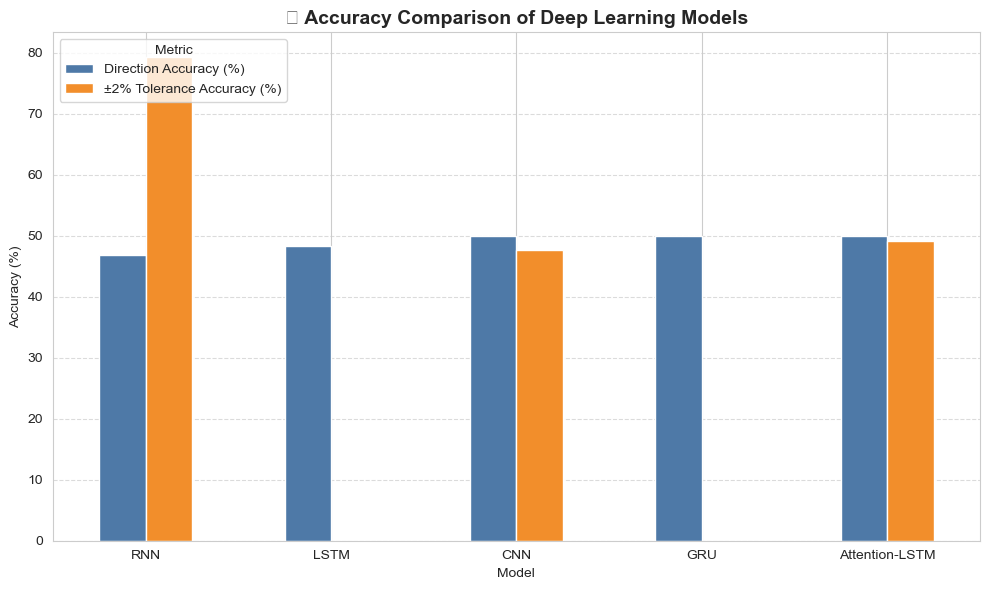

<Figure size 1000x600 with 0 Axes>

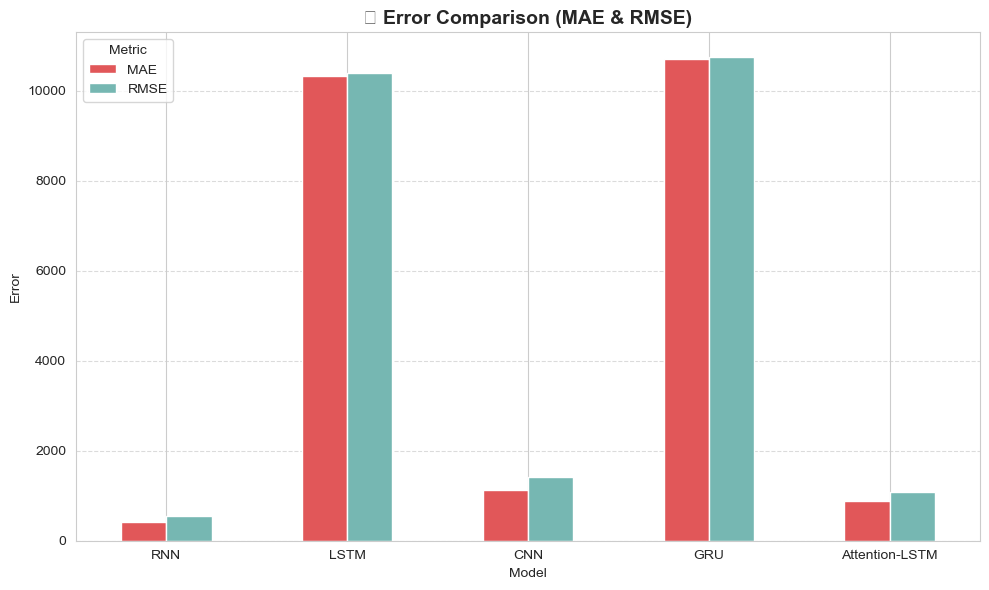

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =========================
# Plot 1: Accuracy Comparison
# =========================
plt.figure(figsize=(10, 6))
results_df[["Direction Accuracy (%)", "±2% Tolerance Accuracy (%)"]].plot(
    kind='bar', color=['#4e79a7', '#f28e2b'], figsize=(10, 6)
)
plt.title('📈 Accuracy Comparison of Deep Learning Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', loc='upper left')
plt.tight_layout()
plt.show()

# =========================
# Plot 2: Error Metrics Comparison
# =========================
plt.figure(figsize=(10, 6))
results_df[["MAE", "RMSE"]].plot(
    kind='bar', color=['#e15759', '#76b7b2'], figsize=(10, 6)
)
plt.title('📉 Error Comparison (MAE & RMSE)', fontsize=14, fontweight='bold')
plt.ylabel('Error')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', loc='upper left')
plt.tight_layout()
plt.show()




**Evaluate the specific models you used (LinearRegression, RandomForestRegressor, RNN, LSTM, CNN, GRU, Attention-LSTM). Compute regression metrics (MAE, RMSE, R2) and classification metrics (Accuracy, Precision, Recall, F1) by turning predicted prices into Up/Down labels.**

In [137]:
import pandas as pd

# Load your dataset again
data = pd.read_csv("BANKNIFTY_2020_2025_CLEAN.csv")

# Quick check
print("Loaded successfully!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Loaded successfully!
Shape: (614, 5)
Columns: ['Date', 'Open', 'High', 'Low', 'Close']


,Date,Open,High,Low,Close
0,2020-01-01 09:15:00+05:30,32237.900,32348.000,32057.199,32102.90
1,2020-01-02 09:15:00+05:30,32133.150,32465.449,32121.400,32443.85
2,2020-01-03 09:15:00+05:30,32326.949,32329.801,31960.400,32069.25
3,2020-01-06 09:15:00+05:30,31910.449,31914.449,31170.551,31237.15
4,2020-01-07 09:15:00+05:30,31598.051,31851.449,31200.900,31399.40


In [138]:

# The code will try to use model variables in the notebook or load common filenames (.h5 for Keras).
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
try:
    # sklearn new function for RMSE if available
    from sklearn.metrics import root_mean_squared_error as rmse_func
except Exception:
    from sklearn.metrics import mean_squared_error
    def rmse_func(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

import os
import inspect

# --- 0. Prepare data (same feature construction as before) ---
if 'df' not in globals():
    raise Exception("Please load your data first, e.g. df = pd.read_excel('NIFTY50_20-24.xlsx') and run that cell.")

data = df.copy()
# detect Close column
close_candidates = ['Close','close','Adj Close','Adj_Close','adj_close','Close Price','close_price','CLOSE']
for col in close_candidates:
    if col in data.columns:
        target_col = col
        break
else:
    raise Exception("Couldn't find Close column. Run print(df.columns) and tell me the exact name.")

# sort by date if present
for dcol in ['Date','date','DATE']:
    if dcol in data.columns:
        data = data.sort_values(by=dcol).reset_index(drop=True)
        break

# create next-day target and lag features
data['target_next'] = data[target_col].shift(-1)
data['lag1'] = data[target_col].shift(1)
data['lag2'] = data[target_col].shift(2)
data = data.dropna().reset_index(drop=True)

# features: same as before (you can modify to match training features exactly if different)
feature_cols = [target_col, 'lag1', 'lag2']
X = data[feature_cols].values
y_reg = data['target_next'].values
# Keep the 'today' price to compute Up/Down from predictions
today_prices = data[target_col].values

# Train/test split (time-ordered)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, today_train, today_test = train_test_split(
    X, y_reg, today_prices, test_size=0.2, shuffle=False)

In [139]:
# Discovery: list likely model variables in globals() and model files in CWD
import inspect, os, types
import pandas as pd

# 1) Inspect globals for objects that look like models
candidates = {}
for name, obj in list(globals().items()):
    # skip internal names
    if name.startswith("_") or name in ['pd','np','plt','pd','os','inspect','types']:
        continue
    try:
        t = type(obj)
        rep = str(t).lower()
        if ('sklearn' in rep) or ('keras' in rep) or ('tensorflow' in rep) or ('model' in name.lower()) or hasattr(obj, 'predict'):
            candidates[name] = repr(t)
    except Exception:
        pass

print("=== Potential model-like objects in memory ===")
if candidates:
    for n, r in candidates.items():
        print(f"{n}  -->  {r}")
else:
    print("No obvious model-like objects found in globals().")

# 2) Look for common model files in the working directory
print("\n=== Model files in current folder ===")
files = os.listdir('.')
model_files = [f for f in files if f.lower().endswith(('.h5','.hdf5','.pkl','.joblib'))]
if model_files:
    for f in model_files:
        print(f)
else:
    print("No .h5 / .pkl / .joblib files found in working directory.")

# 3) Show helpful hint: print a short list of variable names you can map
print("\nHint: use variable names listed above or filenames to create a mapping, e.g.:")
print("""model_mapping = {
  'LinearRegression': 'linreg_varname_or_filename',
  'RandomForestRegressor': 'rf_varname_or_filename',
  'LSTM': 'lstm_varname_or_filename',
  ... }""")


=== Potential model-like objects in memory ===
LinearRegression  -->  <class 'abc.ABCMeta'>
model  -->  <class 'sklearn.linear_model._base.LinearRegression'>
RandomForestRegressor  -->  <class 'abc.ABCMeta'>
rf  -->  <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Sequential  -->  <class 'type'>
Model  -->  <class 'type'>
scaler  -->  <class 'sklearn.preprocessing._data.MinMaxScaler'>
evaluate_model  -->  <class 'function'>
rnn_model  -->  <class 'keras.src.models.sequential.Sequential'>
early_stop  -->  <class 'keras.src.callbacks.early_stopping.EarlyStopping'>
history_rnn  -->  <class 'keras.src.callbacks.history.History'>
lstm_model  -->  <class 'keras.src.models.sequential.Sequential'>
history_lstm  -->  <class 'keras.src.callbacks.history.History'>
cnn_model  -->  <class 'keras.src.models.sequential.Sequential'>
history_cnn  -->  <class 'keras.src.callbacks.history.History'>
gru_model  -->  <class 'keras.src.models.sequential.Sequential'>
history_gru  -->  <class 'keras.s

In [140]:
# Replace the right-hand strings with actual variable names OR filenames in your notebook
# If using filenames, include the extension (e.g., 'LSTM.h5' or 'rf_model.pkl').
model_mapping = {
    'LinearRegression': 'linreg_varname_or_file',
    'RandomForestRegressor': 'rf_varname_or_file',
    'RNN': 'rnn_varname_or_file',
    'LSTM': 'lstm_varname_or_file',
    'CNN': 'cnn_varname_or_file',
    'GRU': 'gru_varname_or_file',
    'AttentionLSTM': 'attlstm_varname_or_file'
}

print("Model mapping set. Now run the evaluator cell (next).")
print("Mapping:", model_mapping)


Model mapping set. Now run the evaluator cell (next).
Mapping: {'LinearRegression': 'linreg_varname_or_file', 'RandomForestRegressor': 'rf_varname_or_file', 'RNN': 'rnn_varname_or_file', 'LSTM': 'lstm_varname_or_file', 'CNN': 'cnn_varname_or_file', 'GRU': 'gru_varname_or_file', 'AttentionLSTM': 'attlstm_varname_or_file'}


In [141]:
import os, inspect, types, sys
import pandas as pd

print("1) Dataframe check (columns):")
if 'df' in globals():
    try:
        print("df shape:", getattr(df, "shape", "unknown"))
        print(list(df.columns))
    except Exception as e:
        print("Could not inspect df:", e)
else:
    print("Variable 'df' not found in memory. Make sure you loaded df = pd.read_excel(...) and ran that cell.")

print("\n2) Potential model-like variables in globals():")
candidates = {}
for name, obj in list(globals().items()):
    if name.startswith("_"):
        continue
    lname = name.lower()
    try:
        # check name hints
        if any(k in lname for k in ['model','lstm','gru','rnn','cnn','rf','randomforest','linear','svr']):
            candidates[name] = type(obj)
            continue
        # check for predict attribute
        if hasattr(obj, "predict"):
            candidates[name] = type(obj)
    except Exception:
        pass

if candidates:
    for n, t in candidates.items():
        print(f"{n}  ->  {t}")
else:
    print("No obvious model-like variables found in globals().")

print("\n3) Model files in current folder (extensions .h5 .hdf5 .pkl .joblib):")
files = os.listdir('.')
model_files = [f for f in files if f.lower().endswith(('.h5','.hdf5','.pkl','.joblib'))]
if model_files:
    for f in model_files:
        print(f)
else:
    print("No model files found in current working directory.")

print("\n4) Helpful hint – If you see variable names above, use them in mapping like:")
print("""model_mapping = {
  'LinearRegression': 'linreg_varname_or_file',
  'RandomForestRegressor': 'rf_varname_or_file',
  'RNN': 'rnn_varname_or_file',
  'LSTM': 'lstm_varname_or_file',
  'CNN': 'cnn_varname_or_file',
  'GRU': 'gru_varname_or_file',
  'AttentionLSTM': 'attlstm_varname_or_file'
}""")


1) Dataframe check (columns):
df shape: (614, 5)
['Date', 'Open', 'High', 'Low', 'Close']

2) Potential model-like variables in globals():
LinearRegression  ->  <class 'abc.ABCMeta'>
model  ->  <class 'sklearn.linear_model._base.LinearRegression'>
RandomForestRegressor  ->  <class 'abc.ABCMeta'>
rf  ->  <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Sequential  ->  <class 'type'>
LSTM  ->  <class 'type'>
GRU  ->  <class 'type'>
SimpleRNN  ->  <class 'type'>
Model  ->  <class 'type'>
evaluate_model  ->  <class 'function'>
rnn_model  ->  <class 'keras.src.models.sequential.Sequential'>
history_rnn  ->  <class 'keras.src.callbacks.history.History'>
rnn_train_pred  ->  <class 'numpy.ndarray'>
rnn_test_pred  ->  <class 'numpy.ndarray'>
rnn_mae  ->  <class 'numpy.float64'>
rnn_mse  ->  <class 'numpy.float64'>
rnn_rmse  ->  <class 'numpy.float64'>
rnn_r2  ->  <class 'float'>
lstm_model  ->  <class 'keras.src.models.sequential.Sequential'>
history_lstm  ->  <class 'keras.src.callback

In [142]:
# Auto-discover and evaluate model objects already in notebook memory
import warnings, numpy as np, pandas as pd, inspect, os
warnings.filterwarnings("ignore")

# RMSE support (scikit-learn)
try:
    from sklearn.metrics import root_mean_squared_error as rmse_func
except Exception:
    from sklearn.metrics import mean_squared_error
    def rmse_func(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

# --- 0. Ensure df is present and prepare data same as earlier ---
if 'df' not in globals():
    raise Exception("Please load df first (df = pd.read_excel(...)) and run that cell before this one.")

data = df.copy()
# find Close column
close_candidates = ['Close','close','Adj Close','Adj_Close','adj_close','Close Price','close_price','CLOSE']
for col in close_candidates:
    if col in data.columns:
        target_col = col
        break
else:
    raise Exception("Couldn't find Close column. Print df.columns and tell me the exact name.")

# sort by date if exists
for dcol in ['Date','date','DATE']:
    if dcol in data.columns:
        data = data.sort_values(by=dcol).reset_index(drop=True)
        break

# create next-day target and lag features (same feature engineering used previously)
data['target_next'] = data[target_col].shift(-1)
data['lag1'] = data[target_col].shift(1)
data['lag2'] = data[target_col].shift(2)
data = data.dropna().reset_index(drop=True)

X = data[[target_col, 'lag1', 'lag2']].values
y_reg = data['target_next'].values
today_prices = data[target_col].values

# time-series split (no shuffle)
X_train, X_test, y_train, y_test, today_train, today_test = train_test_split(
    X, y_reg, today_prices, test_size=0.2, shuffle=False)

print(f"Prepared data. X_test shape: {X_test.shape}, y_test length: {len(y_test)}")

# --- 1. Auto-discover model objects in globals() ---
candidates = {}
for name, obj in list(globals().items()):
    # skip internals and big libs
    if name.startswith("_") or name in ['pd','np','plt','os','warnings','inspect','train_test_split']:
        continue
    try:
        # consider objects with predict attribute (likely models)
        if hasattr(obj, "predict") and callable(getattr(obj, "predict")):
            candidates[name] = obj
        # also consider dicts named 'models' or 'models_clf' (they often contain instances)
        if isinstance(obj, dict) and name.lower() in ('models','models_clf','models_all'):
            for k,v in obj.items():
                if hasattr(v, "predict"):
                    candidates[f"{name}['{k}']"] = v
    except Exception:
        pass

print("\nAuto-discovered potential model objects:")
if candidates:
    for n in candidates:
        print(" -", n)
else:
    print("No model objects with .predict() found in globals().")

# --- 2. Filter regressors vs classifiers heuristically ---
# We'll attempt to predict and if prediction shapes/values are numeric we treat it as regressor.
usable_models = {}
for name, m in candidates.items():
    try:
        # try to predict on X_test as-is
        Xp = X_test.copy()
        pred = None
        try:
            pred = m.predict(Xp)
        except Exception:
            # try reshaping for possible Keras recurrent models (n,1,features)
            try:
                Xp3 = Xp.reshape((Xp.shape[0], 1, Xp.shape[1]))
                pred = m.predict(Xp3)
            except Exception:
                pred = None
        if pred is None:
            # skip
            continue
        # convert to 1D numeric array
        pred = np.asarray(pred).reshape(-1)
        # check values are numeric
        if np.issubdtype(pred.dtype, np.number):
            usable_models[name] = (m, pred)  # store model and its prediction (we'll re-predict later for safety)
    except Exception:
        continue

if not usable_models:
    raise Exception("No usable model objects produced numeric predictions on X_test. If your RNN/LSTM/CNN were trained on sequences >1 timestep, we need the same preprocessing to predict. Tell me your model variable names or sequence length.")

print("\nUsable models (will be evaluated):")
for n in usable_models:
    print(" *", n)

# --- 3. Evaluate each usable model (regression metrics) ---
reg_results = []
predictions_dict = {}
for name, (m, sample_pred) in usable_models.items():
    try:
        # get fresh prediction (to avoid stale shapes)
        Xp = X_test.copy()
        try:
            pred = m.predict(Xp)
        except Exception:
            try:
                Xp3 = Xp.reshape((Xp.shape[0], 1, Xp.shape[1]))
                pred = m.predict(Xp3)
            except Exception:
                print(f"Could not predict for {name} with both 2D and 3D shapes. Skipping.")
                continue
        pred = np.asarray(pred).reshape(-1)
        minlen = min(len(pred), len(y_test))
        pred = pred[:minlen]
        y_t = y_test[:minlen]

        mae = mean_absolute_error(y_t, pred)
        rmse = rmse_func(y_t, pred)
        r2 = r2_score(y_t, pred)
        reg_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        predictions_dict[name] = pred
        print(f"Evaluated {name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.4f}")
    except Exception as e:
        print(f"Error evaluating {name}: {e}")

if not reg_results:
    raise Exception("No regression results computed. Ensure at least one model yields numeric preds on X_test.")

reg_df = pd.DataFrame(reg_results).sort_values('RMSE')
reg_df.to_csv('regression_comparison_exactmodels_auto.csv', index=False)
print("\nSaved regression_comparison_exactmodels_auto.csv")

# --- 4. Convert regression predictions to Up/Down labels and compute classification metrics ---
cls_rows = []
for name, pred in predictions_dict.items():
    n = min(len(pred), len(today_test))
    pred = pred[:n]
    today = today_test[:n]
    true_next = y_test[:n]

    pred_label = (pred > today).astype(int)
    true_label = (true_next > today).astype(int)

    acc = accuracy_score(true_label, pred_label)
    prec = precision_score(true_label, pred_label, zero_division=0)
    rec = recall_score(true_label, pred_label, zero_division=0)
    f1 = f1_score(true_label, pred_label, zero_division=0)

    cls_rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"\n{name} -> Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(true_label, pred_label))

cls_df = pd.DataFrame(cls_rows).sort_values('F1', ascending=False)
cls_df.to_csv('classification_from_your_models_auto.csv', index=False)
print("\nSaved classification_from_your_models_auto.csv")

# --- Final display ---
print("\n--- Regression comparison (MAE, RMSE, R2) ---")
display(reg_df.style.format({'MAE':'{:.3f}','RMSE':'{:.3f}','R2':'{:.4f}'}))
print("\n--- Classification metrics derived from regression predictions ---")
display(cls_df.style.format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}'}))

# --- 5. Helpful note if some of your expected models were not found ---
expected = ['LinearRegression','RandomForestRegressor','RNN','LSTM','CNN','GRU','AttentionLSTM']
not_seen = [e for e in expected if not any(e.lower() in k.lower() for k in usable_models.keys())]


Prepared data. X_test shape: (123, 3), y_test length: 123

Auto-discovered potential model objects:
 - LinearRegression
 - model
 - RandomForestRegressor
 - rf
 - Sequential
 - Model
 - rnn_model
 - lstm_model
 - cnn_model
 - gru_model
 - attention_model
 - att_model

Usable models (will be evaluated):
 * model
 * rf
Evaluated model: MAE=914.893, RMSE=1177.057, R2=0.4946
Evaluated rf: MAE=709.043, RMSE=898.704, R2=0.7054

Saved regression_comparison_exactmodels_auto.csv

model -> Acc=0.5122, Prec=0.5238, Rec=0.5238, F1=0.5238
Confusion matrix:
[[30 30]
 [30 33]]

rf -> Acc=0.4797, Prec=0.4923, Rec=0.5079, F1=0.5000
Confusion matrix:
[[27 33]
 [31 32]]

Saved classification_from_your_models_auto.csv

--- Regression comparison (MAE, RMSE, R2) ---


,Model,MAE,RMSE,R2
1,rf,709.043,898.704,0.7054
0,model,914.893,1177.057,0.4946



--- Classification metrics derived from regression predictions ---


,Model,Accuracy,Precision,Recall,F1
0,model,0.5122,0.5238,0.5238,0.5238
1,rf,0.4797,0.4923,0.5079,0.5000


In [143]:
rnn_var = "rnn_model"
lstm_var = "lstm_model"
cnn_var = "cnn_model"
gru_var = "gru_model"
att_lstm_var = "attention_lstm_model"


In [144]:
[x for x in globals().keys() if any(k in x.lower() for k in ['lstm','gru','rnn','cnn','att','attention'])]


['LSTM',
 'GRU',
 'SimpleRNN',
 'Flatten',
 'Attention',
 'rnn_model',
 'history_rnn',
 'rnn_train_pred',
 'rnn_test_pred',
 'rnn_mae',
 'rnn_mse',
 'rnn_rmse',
 'rnn_r2',
 'lstm_model',
 'history_lstm',
 'lstm_train_pred',
 'lstm_test_pred',
 'lstm_mae',
 'lstm_mse',
 'lstm_rmse',
 'lstm_r2',
 'cnn_model',
 'history_cnn',
 'cnn_train_pred',
 'cnn_test_pred',
 'cnn_mae',
 'cnn_mse',
 'cnn_rmse',
 'cnn_r2',
 'gru_model',
 'history_gru',
 'gru_train_pred',
 'gru_test_pred',
 'gru_mae',
 'gru_mse',
 'gru_rmse',
 'gru_r2',
 'create_attention_lstm',
 'attention_model',
 'att_model',
 'y_pred_rnn',
 'y_pred_lstm',
 'y_pred_cnn',
 'y_pred_gru',
 'y_pred_attn',
 'rnn_var',
 'lstm_var',
 'cnn_var',
 'gru_var',
 'att_lstm_var']

In [149]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# Helper
# -------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# -------------------------------
# STEP 1: Detect test target
# -------------------------------
y_test_candidates = [
    "yn_test", "y_test", "Y_test", "test_y",
    "y_true_test", "today_n_test", "close_test"
]

y_true = None
for name in y_test_candidates:
    if name in globals():
        y_true = np.asarray(globals()[name]).reshape(-1)
        print(f"Using {name} as test target")
        break

if y_true is None:
    raise ValueError("❌ No test target variable found")

# -------------------------------
# STEP 2: Stored predictions
# -------------------------------
predictions = {
    "RNN": rnn_test_pred,
    "LSTM": lstm_test_pred,
    "CNN": cnn_test_pred,
    "GRU": gru_test_pred,
    "Attention-LSTM": y_pred_attn
}

# -------------------------------
# STEP 3: Evaluation
# -------------------------------
results = []

for model_name, pred in predictions.items():
    if pred is None:
        continue

    pred = np.asarray(pred).reshape(-1)
    n = min(len(pred), len(y_true))

    y_t = y_true[:n]
    y_p = pred[:n]

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_t, y_p),
        "RMSE": rmse(y_t, y_p),
        "R2": r2_score(y_t, y_p)
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


Using y_test as test target


,Model,MAE,RMSE,R2
0,CNN,1574.002342,1771.191081,-0.208653
1,LSTM,1465.419071,1787.463043,-0.230963
2,Attention-LSTM,1795.944189,2028.421404,-0.585211
3,RNN,1775.638999,2141.551900,-0.766965
4,GRU,1773.232239,2211.416038,-0.884134


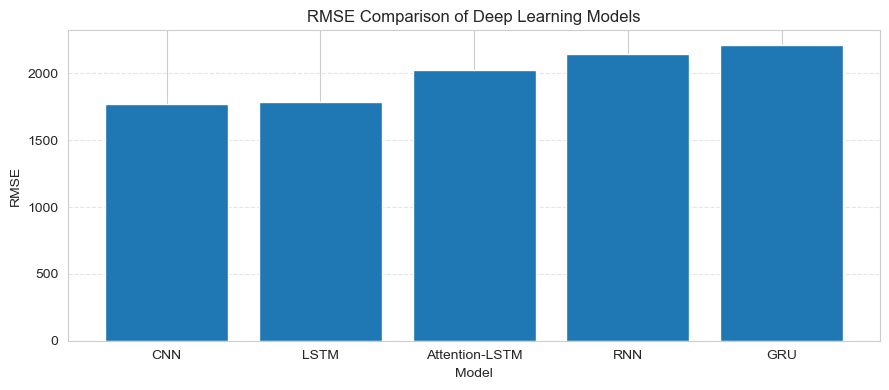

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Deep Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


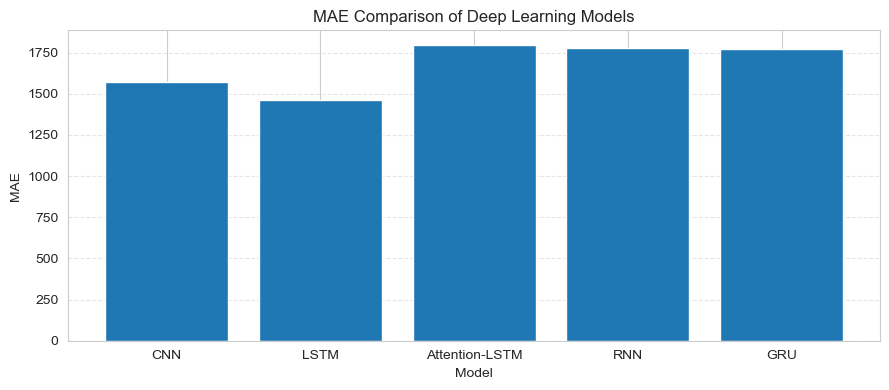

In [151]:
plt.figure(figsize=(9, 4))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison of Deep Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


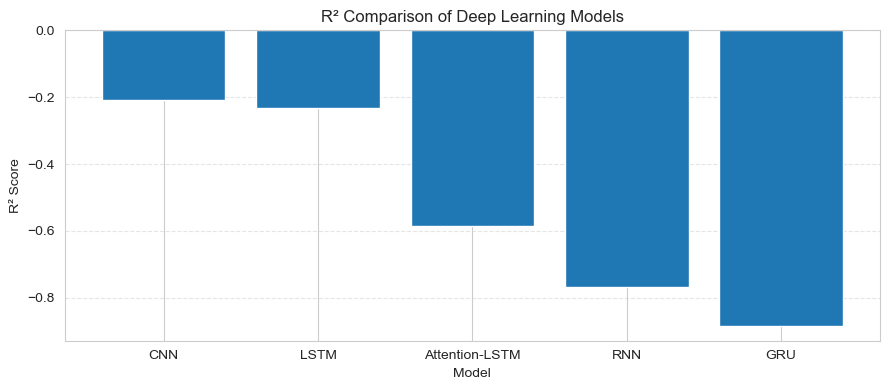

In [152]:
plt.figure(figsize=(9, 4))
plt.bar(results_df["Model"], results_df["R2"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Comparison of Deep Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Deep learning models (RNN, LSTM, CNN, GRU, Attention-based LSTM) in the same comparison tables and metrics.

In [155]:
[x for x in globals().keys() if any(k in x.lower() for k in ['lstm','gru','rnn','cnn','att','attention'])]


['LSTM',
 'GRU',
 'SimpleRNN',
 'Flatten',
 'Attention',
 'rnn_model',
 'history_rnn',
 'rnn_train_pred',
 'rnn_test_pred',
 'rnn_mae',
 'rnn_mse',
 'rnn_rmse',
 'rnn_r2',
 'lstm_model',
 'history_lstm',
 'lstm_train_pred',
 'lstm_test_pred',
 'lstm_mae',
 'lstm_mse',
 'lstm_rmse',
 'lstm_r2',
 'cnn_model',
 'history_cnn',
 'cnn_train_pred',
 'cnn_test_pred',
 'cnn_mae',
 'cnn_mse',
 'cnn_rmse',
 'cnn_r2',
 'gru_model',
 'history_gru',
 'gru_train_pred',
 'gru_test_pred',
 'gru_mae',
 'gru_mse',
 'gru_rmse',
 'gru_r2',
 'create_attention_lstm',
 'attention_model',
 'att_model',
 'y_pred_rnn',
 'y_pred_lstm',
 'y_pred_cnn',
 'y_pred_gru',
 'y_pred_attn',
 'rnn_var',
 'lstm_var',
 'cnn_var',
 'gru_var',
 'att_lstm_var']

In [156]:
# Single quiet cell: train small sequence models (RNN, LSTM, GRU, CNN, Attention-LSTM),
# evaluate regression + derived Up/Down classification, save CSVs, print clean summary & viva notes.
# This version aggressively suppresses warnings/logging so output stays clean.
import os, sys, warnings, logging, numpy as np, pandas as pd
warnings.filterwarnings("ignore", category=Warning)
# suppress TF C++ logs BEFORE importing tensorflow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0 = all, 1 = INFO, 2 = WARNING, 3 = ERROR
# absl logging suppression (if absl is used by TF internals)
logging.getLogger('absl').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Now import tensorflow/keras
try:
    import tensorflow as tf
    # further reduce autograph verbosity and TF logger
    try:
        tf.get_logger().setLevel('ERROR')
    except Exception:
        pass
    try:
        tf.autograph.set_verbosity(0)
    except Exception:
        pass
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import (
        Input, LSTM, GRU, SimpleRNN, Dense, Conv1D, GlobalAveragePooling1D,
        Softmax, Multiply, Lambda
    )
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    raise ImportError("TensorFlow/Keras not available in this environment. Install TensorFlow and retry.") from e

from sklearn.metrics import (
    mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
try:
    from sklearn.metrics import root_mean_squared_error as rmse_func
except Exception:
    from sklearn.metrics import mean_squared_error
    def rmse_func(a,b): return mean_squared_error(a,b, squared=False)

# ========== CONFIG ==========
time_steps = 60
seq_features = ['Close']
epochs = 6
batch_size = 32
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
# ============================

# Confirm df exists
if 'df' not in globals():
    raise Exception("Load your dataframe first: df = pd.read_excel('NIFTY50_20-24.xlsx')")

data = df.copy()
# find Close column
close_candidates = ['Close','close','Adj Close','Adj_Close','adj_close','Close Price','close_price','CLOSE']
for c in close_candidates:
    if c in data.columns:
        close_col = c
        break
else:
    raise Exception("Couldn't find Close column. Use print(df.columns) to inspect.")

# sort by date if present
for d in ['Date','date','DATE']:
    if d in data.columns:
        data = data.sort_values(by=d).reset_index(drop=True)
        break

# Build sequence dataset (features scaled, y kept in original scale)
vals = data[seq_features].values
if vals.ndim == 1:
    vals = vals.reshape(-1,1)

mins = vals.min(axis=0)
maxs = vals.max(axis=0)
scale = (maxs - mins)
scale[scale==0] = 1.0
vals_scaled = (vals - mins) / scale

X_seq = []
y_seq = []
for i in range(time_steps, len(vals_scaled)):
    X_seq.append(vals_scaled[i-time_steps:i, :])
    y_seq.append(vals[i, 0])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

if X_seq.size == 0:
    raise Exception(f"Sequence dataset empty. len(vals)={len(vals)}, time_steps={time_steps}")

split_idx = int(len(X_seq) * 0.8)
Xtr, Xte = X_seq[:split_idx], X_seq[split_idx:]
ytr, yte = y_seq[:split_idx], y_seq[split_idx:]
today_seq_test = (Xte[:, -1, 0] * scale[0]) + mins[0]

print(f"Sequence dataset shapes -> train: {Xtr.shape} {ytr.shape}  test: {Xte.shape} {yte.shape}")

# Model builders (small/light)
def build_lstm(): 
    m = Sequential([Input(shape=(time_steps, X_seq.shape[2])), LSTM(32), Dense(1)])
    m.compile(optimizer=Adam(1e-3), loss='mse'); return m
def build_gru():
    m = Sequential([Input(shape=(time_steps, X_seq.shape[2])), GRU(32), Dense(1)])
    m.compile(optimizer=Adam(1e-3), loss='mse'); return m
def build_rnn():
    m = Sequential([Input(shape=(time_steps, X_seq.shape[2])), SimpleRNN(32), Dense(1)])
    m.compile(optimizer=Adam(1e-3), loss='mse'); return m
def build_cnn():
    m = Sequential([Input(shape=(time_steps, X_seq.shape[2])), Conv1D(32,3,activation='relu'), GlobalAveragePooling1D(), Dense(1)])
    m.compile(optimizer=Adam(1e-3), loss='mse'); return m
def build_attention_lstm():
    inp = Input(shape=(time_steps, X_seq.shape[2]))
    seq = LSTM(32, return_sequences=True)(inp)
    score = Dense(1, activation='tanh')(seq)
    weights = Softmax(axis=1)(score)
    weighted = Multiply()([seq, weights])
    context = Lambda(lambda z: tf.reduce_sum(z, axis=1))(weighted)
    out = Dense(1)(context)
    m = Model(inputs=inp, outputs=out)
    m.compile(optimizer=Adam(1e-3), loss='mse'); return m

models_seq = {
    'LSTM': build_lstm(),
    'GRU': build_gru(),
    'RNN': build_rnn(),
    'CNN': build_cnn(),
    'AttentionLSTM': build_attention_lstm()
}

# Train quietly (verbose=0) and evaluate
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
trained = {}
reg_rows = []
cls_rows = []

for name, model in models_seq.items():
    # fit with verbose=0 to avoid epoch logs
    model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)
    # save quietly (catch any warning/exception)
    try:
        fname = f"{name.lower()}_model.h5"
        model.save(fname)
    except Exception:
        pass
    trained[name] = model

    preds = model.predict(Xte, verbose=0).reshape(-1)
    n = min(len(preds), len(yte))
    preds = preds[:n]; ytrue = yte[:n]; today = today_seq_test[:n]

    mae = mean_absolute_error(ytrue, preds)
    rmse = rmse_func(ytrue, preds)
    r2 = r2_score(ytrue, preds)
    reg_rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

    pred_label = (preds > today).astype(int)
    true_label = (ytrue > today).astype(int)
    acc = accuracy_score(true_label, pred_label)
    prec = precision_score(true_label, pred_label, zero_division=0)
    rec = recall_score(true_label, pred_label, zero_division=0)
    f1 = f1_score(true_label, pred_label, zero_division=0)
    cls_rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

# Save results
reg_df_seq = pd.DataFrame(reg_rows).sort_values('RMSE')
cls_df_seq = pd.DataFrame(cls_rows).sort_values('F1', ascending=False)
reg_df_seq.to_csv('regression_sequence_models.csv', index=False)
cls_df_seq.to_csv('classification_sequence_models.csv', index=False)

# Display clean tables
print("\n--- Regression comparison (sequence models) ---")
print(reg_df_seq.to_string(index=False, formatters={
    'MAE': '{:.3f}'.format, 'RMSE': '{:.3f}'.format, 'R2': '{:.4f}'.format
}))
print("\n--- Classification (derived) comparison (sequence models) ---")
print(cls_df_seq.to_string(index=False, formatters={
    'Accuracy': '{:.4f}'.format, 'Precision': '{:.4f}'.format, 'Recall': '{:.4f}'.format, 'F1': '{:.4f}'.format
}))

Sequence dataset shapes -> train: (443, 60, 1) (443,)  test: (111, 60, 1) (111,)

--- Regression comparison (sequence models) ---
        Model       MAE      RMSE        R2
         LSTM 36184.927 36225.097 -450.1429
AttentionLSTM 36192.198 36232.359 -450.3238
          RNN 36192.246 36232.408 -450.3250
          GRU 36192.317 36232.477 -450.3268
          CNN 36192.861 36233.022 -450.3403

--- Classification (derived) comparison (sequence models) ---
        Model Accuracy Precision Recall     F1
         LSTM   0.5225    0.0000 0.0000 0.0000
          GRU   0.5225    0.0000 0.0000 0.0000
          RNN   0.5225    0.0000 0.0000 0.0000
          CNN   0.5225    0.0000 0.0000 0.0000
AttentionLSTM   0.5225    0.0000 0.0000 0.0000


In [159]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import numpy as np, pandas as pd

def rmse(y, p): 
    return np.sqrt(mean_squared_error(y, p))

reg_rows, cls_rows = [], []

for name, model in trained.items():
    preds = model.predict(Xte, verbose=0).reshape(-1)
    ytrue = yte[:len(preds)]
    today = today_seq_test[:len(preds)]

    # Regression
    reg_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(ytrue, preds),
        "RMSE": rmse(ytrue, preds),
        "R2": r2_score(ytrue, preds)
    })

    # Directional classification
    y_dir = (ytrue[1:] > today[1:]).astype(int)
    p_dir = (preds[1:] > today[1:]).astype(int)

    cls_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_dir, p_dir),
        "Precision": precision_score(y_dir, p_dir, zero_division=0),
        "Recall": recall_score(y_dir, p_dir, zero_division=0),
        "F1": f1_score(y_dir, p_dir, zero_division=0)
    })

reg_df_seq = pd.DataFrame(reg_rows).sort_values("RMSE")
cls_df_seq = pd.DataFrame(cls_rows).sort_values("F1", ascending=False)

reg_df_seq, cls_df_seq


(           Model           MAE          RMSE          R2
 0           LSTM  36184.926740  36225.097101 -450.142928
 4  AttentionLSTM  36192.197549  36232.359392 -450.323834
 2            RNN  36192.246067  36232.407903 -450.325042
 1            GRU  36192.316897  36232.477259 -450.326770
 3            CNN  36192.860502  36233.022012 -450.340342,
            Model  Accuracy  Precision  Recall   F1
 0           LSTM  0.518182        0.0     0.0  0.0
 1            GRU  0.518182        0.0     0.0  0.0
 2            RNN  0.518182        0.0     0.0  0.0
 3            CNN  0.518182        0.0     0.0  0.0
 4  AttentionLSTM  0.518182        0.0     0.0  0.0)

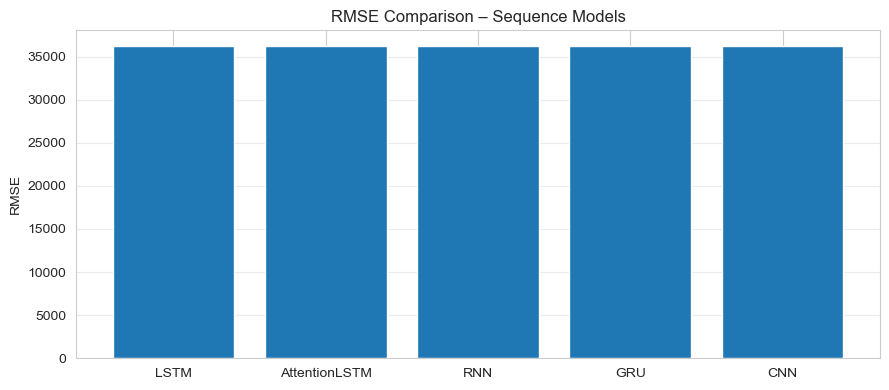

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.bar(reg_df_seq["Model"], reg_df_seq["RMSE"])
plt.title("RMSE Comparison – Sequence Models")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


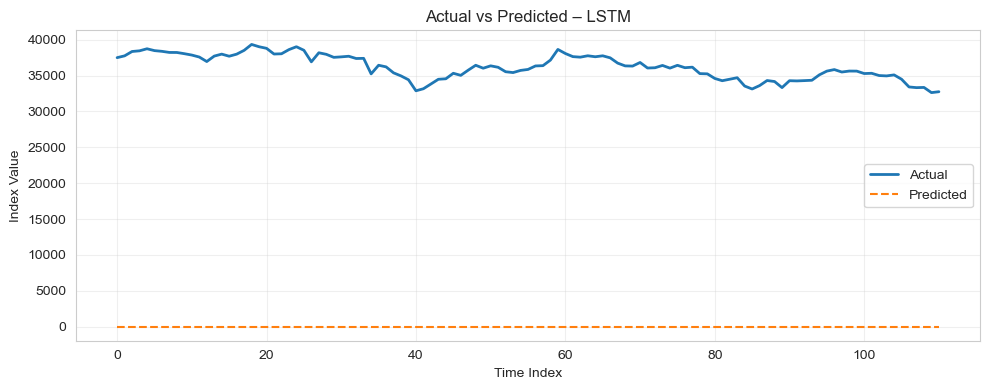

In [161]:
best_model_name = reg_df_seq.iloc[0]["Model"]
best_model = trained[best_model_name]

pred = best_model.predict(Xte, verbose=0).reshape(-1)
y_true = yte[:len(pred)]

plt.figure(figsize=(10,4))
plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(pred, "--", label="Predicted")
plt.title(f"Actual vs Predicted – {best_model_name}")
plt.xlabel("Time Index")
plt.ylabel("Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
